<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd
import numpy as np
import matplotlib as plt
import scipy.stats as stats
import missingno as msno
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Importation de la librairie plotly express
import plotly.express as px

In [3]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir, dans Google, les mots clés "display all columns dataframe Pandas", par exemple.
#Dans les résultats de la recherche, privilégiez les solutions provenants de Stack Overflow ou Medium
pd.set_option('display.max_columns', None)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [4]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("/content/web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("/content/erp.xlsx")
#importation du fichier liaison.xlsx
df_liaison = pd.read_excel("/content/liaison.xlsx")

/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [5]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [6]:
#Consulter le nombre de colonnes
print("Le nombre de est de :",df_erp.shape[1], "colonne(s)")
#La nature des données dans chacune des colonnes
print("\n La nature de chacune des colonnes est :","\n", df_erp.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
print("\n Le nombre de valeurs présentes dans chacune des colonnes :","\n", df_erp.info())

Le nombre de est de : 6 colonne(s)

 La nature de chacune des colonnes est : 
 product_id          int64
onsale_web          int64
price             float64
stock_quantity      int64
stock_status       object
purchase_price    float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB

 Le nombre de valeurs présentes dans chacune des colonnes : 
 None


In [7]:
#Afficher les 5 premières lignes de la table
print(df_erp.head())

   product_id  onsale_web  price  stock_quantity stock_status  purchase_price
0        3847           1   24.2              16      instock           12.88
1        3849           1   34.3              10      instock           17.54
2        3850           1   20.8               0   outofstock           10.64
3        4032           1   14.1              26      instock            6.92
4        4039           1   46.0               3   outofstock           23.77


In [8]:
#Vérifier si il y a les lignes en doublons dans la colonne product_id
doublons_erp = df_erp[df_erp.duplicated(subset=["product_id"])]
print(doublons_erp)

Empty DataFrame
Columns: [product_id, onsale_web, price, stock_quantity, stock_status, purchase_price]
Index: []


In [9]:
#Afficher les valeurs distinctes de la colonne stock_status
nombre_valeurs_uniques = df_erp["stock_status"].nunique()
print(nombre_valeurs_uniques)
valeurs_uniques = df_erp["stock_status"].unique()
print(valeurs_uniques)

2
['instock' 'outofstock']


In [10]:
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
df_erp['onsale_web'].value_counts()

,count
onsale_web,
1,716
0,109


La sortie montre que la majorité des articles ont la valeur 1 pour onsale_web soit 716 artciles ce qui représente environ 83%.
Cela indique qu'une grande partie des articles sont disponible à la vente en ligne, alors qu'une minorité, 109 articles, présente l'état 0.
En d'autres termes, ces articles ne sont pas vendus en ligne soit environ 17 % de l'assortiment.

In [11]:
print(df_erp.columns)

Index(['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status',
       'purchase_price'],
      dtype='object')


In [12]:
#Création d'une colonne "stock_status_2
df_erp["stock_status_2"] = df_erp["stock_status"]
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#si la valeur de la colonne "stock_quantity" est nulle renseigner "outofstock" sinon mettre "instock"
df_erp["stock_status_2"] = df_erp["stock_quantity"].apply(lambda x: "outofstock" if x == 0 else "instock")

In [13]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:

comparaison = df_erp['stock_status'] == df_erp['stock_status_2']

#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
true_count = comparaison.sum()
false_count = len(comparaison) - true_count

print(f"Nombre de valeurs identiques (True): {true_count}")
print(f"Nombre de valeurs différents (False): {false_count}")

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

Nombre de valeurs identiques (True): 821
Nombre de valeurs différents (False): 4


In [14]:
df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


In [15]:
# Afficher les lignes différentes
comparaison.loc[comparaison == False]

,0
4,False
398,False
449,False
573,False


In [16]:
df_erp.iloc[[4, 398, 449, 573],:]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


In [18]:
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
nombre_instock = (df_erp["stock_status"] == "instock").sum()
nombre_outofstock = (df_erp["stock_status"] == "outofstock").sum()
nombre_de_lignes = nombre_instock + nombre_outofstock
print("Il y a ", nombre_de_lignes,"lignes")

Il y a  825 lignes


In [19]:
nb_de_lignes_erp = true_count + false_count
print(f"Le nombre de lignes est de {nb_de_lignes_erp}")

Le nombre de lignes est de 825


In [20]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3

In [21]:
#Corriger la ou les données incohérentes

# 1. Transformer les valeurs 'stock_status_2' lorsque le statut correspond à la quantité en stock
df_erp.iloc[4, df_erp.columns.get_loc('stock_status')] = df_erp.iloc[4, df_erp.columns.get_loc('stock_status_2')]

# 2. Mettre à jour 'stock_status' à "outofstock" pour les lignes où 'stock_quantity' est désormais 0
df_erp.loc[df_erp['stock_quantity'] == 0, 'stock_status'] = 'outofstock'

#Verification en utilisant le même code que plus haut pour afficher les problemes
comparaison = df_erp['stock_status'] == df_erp['stock_status_2']
true_count = comparaison.sum()
false_count = len(comparaison) - true_count

print(f"Nombre de valeurs identiques (True): {true_count}")
print(f"Nombre de valeurs différents (False): {false_count}")

Nombre de valeurs identiques (True): 823
Nombre de valeurs différents (False): 2


In [22]:
# Afficher les deux valeurs différentes
df_erp[df_erp['stock_status'] != df_erp['stock_status_2']]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


Pour ces deux observations restantes, la variable stock_status contient désormais les valeurs validées après échanges avec les équipes métiers, ce qui en fait la valeur correcte pour cette variable.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [23]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatif ou nul?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'article avec un prix non renseignés: {}".format(
    df_erp[(df_erp["price"].isna()) | (df_erp["price"] <= 0)].shape[0]
)) #Saisir l'instruction manquante dans la fonction format


Nombres d'article avec un prix non renseignés: 3


In [24]:
#Afficher le prix minimum de la colonne "price"
print(f"Le prix minimum est de {df_erp['price'].min()}")

Le prix minimum est de -20.0


In [25]:
#Afficher le prix maximum de la colonne "price"
print(f"Le prix maximum est de {(df_erp['price'].max())}")

Le prix maximum est de 225.0


In [26]:
#Affichier les prix inférieurs à 0 (qu'est ce qu'il faut en faire ?)
print(f"Les prix inférieurs à 0 sont {df_erp.query('price <0')}")
# 1) Isoler ces références
# 2) Communiquer avec l'expert métier
#3) Mettre en place des mesures correctives, le cas échéant

Les prix inférieurs à 0 sont      product_id  onsale_web  price  stock_quantity stock_status  \
151        4233           0  -20.0               0   outofstock   
469        5017           0   -8.0               0   outofstock   
739        6594           0   -9.1              19      instock   

     purchase_price stock_status_2  
151           10.33     outofstock  
469            4.34     outofstock  
739            4.61        instock  


In [27]:
df_erp['price'] = df_erp['price'].abs()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [28]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
print(df_erp['stock_quantity'].describe())


count    825.000000
mean      21.589091
std       21.933807
min      -10.000000
25%        7.000000
50%       18.000000
75%       30.000000
max      145.000000
Name: stock_quantity, dtype: float64


In [29]:
df_erp["stock_quantity"].isna().sum()

np.int64(0)

<Axes: >

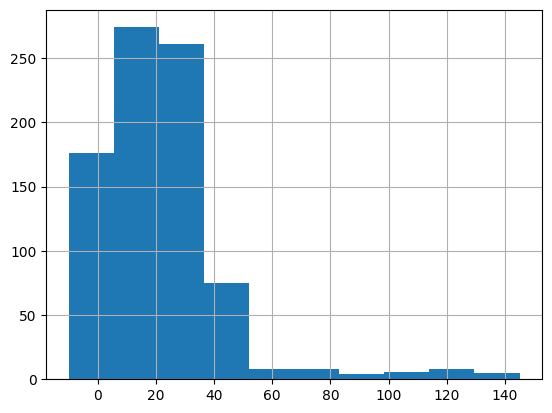

In [30]:
df_erp["stock_quantity"].hist()

In [31]:
#Afficher la quantité minimum de la colonne "stock_quantity"
print(f"La quantité minimun de la colonne est {(df_erp['stock_quantity'].min())} ")

La quantité minimun de la colonne est -10 


In [32]:
#Afficher la quantité maximum de la colonne "stock_quantity"
print(f"La quantité maximum de la colonne est {(df_erp['stock_quantity'].max())}")

La quantité maximum de la colonne est 145


In [33]:
#Affichier les stocks inférieurs à 0 (qu'est ce qu'il faut en faire ?)
print(f"Les stocks inférieurs à 0 sont {(df_erp[df_erp['stock_quantity'] <0] ['stock_quantity'].tolist())}")
# 1) Isoler ces références
# 2) Communiquer avec les équipes métiers
#3) Mettre en place des mesures correctives, le cas échéant


Les stocks inférieurs à 0 sont [-10, -1]


Il y également ici des erreurs avec des valeurs de stocks négatives : -10 et -1.

In [34]:
# Affichage des valeurs de stocks négatives
df_erp.query('stock_quantity <0')

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


In [35]:
print(df_erp[df_erp['stock_quantity']<0] ['stock_quantity'].tolist())

[-10, -1]


In [36]:
# Après communiquer cette information à l'équipe métier, transformer les valeurs négatives en sa contrepartie positive
# tout en conservant les valeurs déjà positives
df_erp['stock_quantity'] = df_erp['stock_quantity'].abs()

In [37]:
# Vérification de la mise à jour
print(f"Les valeurs de stock inférieures à 0 sont : \n {df_erp.query('stock_quantity <0')}")

Les valeurs de stock inférieures à 0 sont : 
 Empty DataFrame
Columns: [product_id, onsale_web, price, stock_quantity, stock_status, purchase_price, stock_status_2]
Index: []


La mise à jour à bien été effectuée.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [38]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient? Que signifient-elles?
print(df_erp["onsale_web"])

0      1
1      1
2      1
3      1
4      1
      ..
820    0
821    0
822    1
823    0
824    1
Name: onsale_web, Length: 825, dtype: int64


Les valeurs que contiennent ces colonnes sont de type booléens.
Par conséquent, leur signification est la suivante :
- 1=True > vente en ligne
- 0=False > vente en magasin

In [39]:
#Quelles sont les colonnes à conserver selon vous?

Toutes les colonnes sont à conserver car, ces variables sont significatives et jouent un rôle prépondérant par rapport au besoin métier tant sur le plan opérationnel que stratégique.
- product_id >> permet d'identifer chaque article de manière unique
- onsale_web >> identique les articles vendus en ligne ou en magasin
- price >> correspond au prix de l'article
- stock_quantity >> la quantité d'article en stock
- stock_status >> renseigne sur la disponibilité de l'article
- et enfin purchase_price représente le prix d'achat de l'article

Les colonnes à conserver sont : [
    'product_id',
    'onsale_web',
    'price',
    'stock_quantity',
    'stock_status',
    'purchase_price'
]

In [40]:
#Supprimer la colonnecomportant le libellé "stock_status_2" car elle est redondante
#avec la colonne "stock_status".
df_erp.drop(['stock_status', 'stock_status_2'], axis=1, inplace=True)


In [41]:
print(df_erp.head())

   product_id  onsale_web  price  stock_quantity  purchase_price
0        3847           1   24.2              16           12.88
1        3849           1   34.3              10           17.54
2        3850           1   20.8               0           10.64
3        4032           1   14.1              26            6.92
4        4039           1   46.0               3           23.77


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [42]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price :
print(df_erp["purchase_price"].describe())

#Afficher le prix minimum de la colonne "purchase_price"
print(f"Le prix minimum de la colonnes purchase_price est de : {df_erp['purchase_price'].min()} €")

#Afficher le prix maximum de la colonne "purchase_price"
print(f"Le prix maximum de la colonnes purchase_price est de : {df_erp['purchase_price'].max()} €")


count    825.000000
mean      16.940582
std       14.561840
min        2.740000
25%        7.590000
50%       12.710000
75%       22.020000
max      137.810000
Name: purchase_price, dtype: float64
Le prix minimum de la colonnes purchase_price est de : 2.74 €
Le prix maximum de la colonnes purchase_price est de : 137.81 €


In [43]:
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
prix_non_renseignes = df_erp.loc[df_erp["purchase_price"]< 0, "purchase_price"].tolist()
print(prix_non_renseignes)
df_erp.query("purchase_price <0")

[]


,product_id,onsale_web,price,stock_quantity,purchase_price


A priori, il n'y a pas d'erreurs dans cette variable pour les prix.

In [44]:
df_erp = df_erp.astype({'product_id': str, 'onsale_web': bool})
df_erp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    object 
 1   onsale_web      825 non-null    bool   
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   purchase_price  825 non-null    float64
dtypes: bool(1), float64(2), int64(1), object(1)
memory usage: 26.7+ KB


Ces conversions permettent de garantir la sécurité et la cohérence des données des variables concernées.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>


In [45]:
#Dimension du dataset
print(f"La dimension du dataset est {df_web.shape}")

#Nombre d'observations
nombre_observations = df_web.shape[0]
print(f"Le nombre d'observations du dataset est de {nombre_observations}")

#Nombre de caractéristiques
nombre_caracteristiques = len(df_web.columns)
print(f"Le nombre de caractéristiques du dataset est de {nombre_caracteristiques}")

La dimension du dataset est (1513, 29)
Le nombre d'observations du dataset est de 1513
Le nombre de caractéristiques du dataset est de 29


In [46]:
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

In [47]:
#Consulter le nombre de colonnes
print(f"Le nombre de colonnes est {df_web.shape[1]}.")
#La nature des données dans chacune des colonnes
print(f"La nature des données dans chacune des colonnes : \n{df_web.dtypes}")
#Le nombre de valeurs présentes dans chacune des colonnes
print(f"Le nombre de valeurs présentes dans chacune des colonnes :\n{df_web.count()}")

Le nombre de colonnes est 29.
La nature des données dans chacune des colonnes : 
sku                              object
virtual                           int64
downloadable                      int64
rating_count                      int64
average_rating                  float64
total_sales                     float64
tax_status                       object
tax_class                       float64
post_author                     float64
post_date                datetime64[ns]
post_date_gmt            datetime64[ns]
post_content                    float64
product_type                     object
post_title                       object
post_excerpt                     object
post_status                      object
comment_status                   object
ping_status                      object
post_password                   float64
post_name                        object
post_modified            datetime64[ns]
post_modified_gmt        datetime64[ns]
post_content_filtered           float64

In [48]:
#Selon vous, quelles sont les colonnes à conserver ?

    "sku"           # Code produit unique
    "total_sales"   # Total des ventes, indicateur de performance commerciale
    "post_date"    # Date de mise en ligne, clé pour l'analyse temporelle
    "product_type"  # Typologie du produit pour la segmentation
    "post_title"     # Titre du produit pour identification


In [49]:
# Colonnes à supprimer
col_a_supprimer =[1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
df_web.drop(df_web.columns[col_a_supprimer], axis=1, inplace=True)

In [50]:
print(df_web['sku'].value_counts())

sku
14569    2
11862    2
16057    2
14692    2
16295    2
        ..
15575    2
12869    2
15526    2
16269    2
16585    2
Name: count, Length: 714, dtype: int64


In [51]:
df_web = df_web.drop_duplicates(subset=['sku'], keep='first')


In [52]:
print(df_web)

        sku  total_sales product_type  \
0     11862          3.0          Vin   
1     16057          5.0          Vin   
2     14692          5.0          Vin   
3     16295         14.0          Vin   
4     15328          2.0          Vin   
...     ...          ...          ...   
1325  16043         10.0          Vin   
1327  15845          9.0          Vin   
1339  15951          9.0          Vin   
1353  13074          4.0          Vin   
1391  14569         13.0          Vin   

                                             post_title  
0                     Gilles Robin Hermitage Rouge 2012  
1     Domaine Pellé Sancerre Rouge La Croix Au Garde...  
2         Château Fonréaud Bordeaux Blanc Le Cygne 2016  
3     Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...  
4                  Agnès Levet Côte Rôtie Maestria 2017  
...                                                 ...  
1325            Pierre Gaillard Saint-Joseph Rouge 2018  
1327    Château Jean Faure Saint-Emilion Gr

In [53]:
df_web.info()

<class 'pandas.core.frame.DataFrame'>
Index: 715 entries, 0 to 1391
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           714 non-null    object 
 1   total_sales   714 non-null    float64
 2   product_type  714 non-null    object 
 3   post_title    714 non-null    object 
dtypes: float64(1), object(3)
memory usage: 27.9+ KB


In [54]:
df_web = df_web.dropna(how='all')

<Axes: >

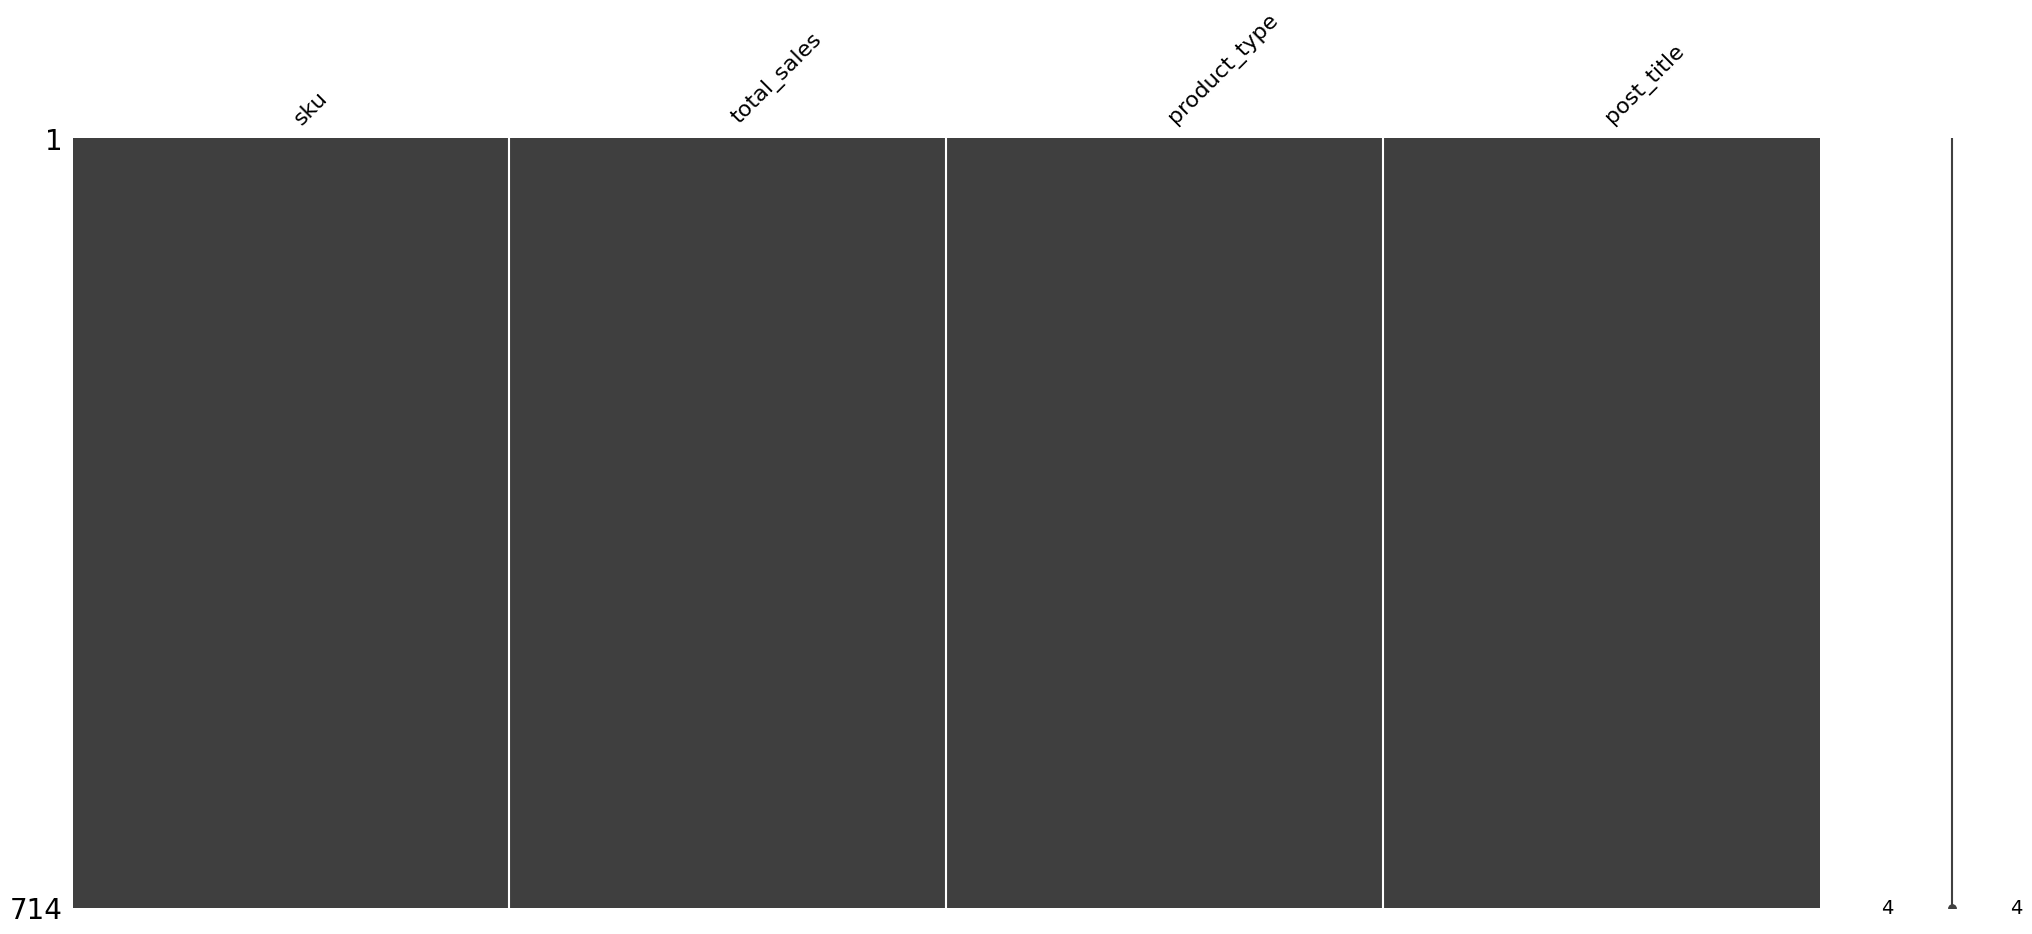

In [55]:
msno.matrix(df_web)

In [56]:
#Visualisation des valeurs de la colonne sku
fig = px.histogram(df_web,
                   x="sku",
                   nbins=30,
                   title="Histogramme des valeurs de SKU")
fig.show()

In [57]:
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?

# 1. S'assurer que la colonne 'sku' est de type chaîne de cractères et retirer les espaces inutiles
df_web['sku'] = df_web['sku'].astype(str).str.strip()

In [58]:
2. # Afficher l'observation qui présente une anomalie
df_web.query('product_type.isna()')

,sku,total_sales,product_type,post_title


In [59]:
#Visualisation des valeurs de la colonne sku
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les?
df_web['sku'].unique()

array(['11862', '16057', '14692', '16295', '15328', '15471', '16515',
       '16246', '13572', '16513', '16585', '16269', '15526', '12869',
       '15575', '11586', '14338', '15425', '16560', '15361', '13809',
       '11587', '15022', '14323', '16342', '16029', '15475', '13754',
       '14680', '15875', '9636', '13849', '13662', '16564', '13557',
       '15429', '14712', '15032', '15481', '15448', '16580', '15441',
       '804', '15300', '13958', '16071', '15678', '13895', '15711',
       '12882', '16053', '13766', '16247', '12640', '15292', '15476',
       '15670', '16189', '16038', '14864', '16044', '15324', '15531',
       '15953', '15413', '15733', '14366', '15895', '15892', '16472',
       '15185', '16010', '15793', '15849', '12315', '15741', '15934',
       '15148', '15781', '15659', '15106', '15490', '14507', '14149',
       '16307', '13736', '14090', '16037', '15758', '14661', '12587',
       '15337', '15489', '15201', '16305', '16131', '13435', '15747',
       '12203', '14509'

 'bon_cadeau-25-euros', '13127-1' et 'nan' ne respectent pas la règle de codification.

In [60]:
#Identifier les lignes sans code articles
lignes_sans_code_articles = df_web[df_web['sku'].isna()]
print(lignes_sans_code_articles)

Empty DataFrame
Columns: [sku, total_sales, product_type, post_title]
Index: []


In [61]:
#Pour les codes articles identifiés, réalisé une analyse et définissez l'action à entreprendre


**Il n'y a pas d'observations sans code articles.**

In [62]:
#La clé pour chaque ligne est-elle uniques? ou autrement dit, y a-t-il des doublons?
df_web.loc[df_web['sku'].duplicated(keep=False)]

,sku,total_sales,product_type,post_title


In [63]:
# Supprimer les doublons
df_web = df_web.drop_duplicates(subset=['sku'], keep='first')



In [64]:
# Convertir de 'sku' en stra afin d'effectuer le tri
df_web['sku'] = df_web['sku'].astype(str)

df_web_sorted = df_web.sort_values(by='sku')
df_web_doublons_sku = df_web_sorted.groupby('sku')

Analyse bon cadeau

In [65]:
# Affichage du doublon sur 'poste_title'
df_web.query("post_title == 'Bon cadeau de 25€'")

,sku,total_sales,product_type,post_title
842,bon-cadeau-25-euros,7.0,Autre,Bon cadeau de 25€


In [66]:
# Remplacer nan apr 'Autre' uniquement pour les observations où 'sku' est 'bon-cadeau-25-euros'
df_web.loc[(df_web['sku'] == 'bon-cadeau-25-euros') & (df_web['product_type'].isna()), 'product_type'] = 'Autre'

In [67]:
df_web.query("post_title == 'Bon cadeau de 25€'")

,sku,total_sales,product_type,post_title
842,bon-cadeau-25-euros,7.0,Autre,Bon cadeau de 25€


Focus sur le 'sku' '13127-1'

In [68]:
df_web.query("sku == '13127-1'")

,sku,total_sales,product_type,post_title
272,13127-1,4.0,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007


Focus sur les observations nan pour 'sku'

In [69]:
df_web.query("sku == 'nan'")

,sku,total_sales,product_type,post_title


In [70]:
df_web.query("post_title == 'Pierre Jean Villa Condrieu Jardin Suspendu 2018' | post_title == 'Pierre Jean Villa Côte Rôtie Fongeant 2017'")

,sku,total_sales,product_type,post_title


Supprimer de ces observations car il n'y a pas de doublons via 'attachment'. De plus, total_sales est une valeur négative.

Communiquer à l'équipe métier puis cleaned.


In [71]:
df_web = df_web[df_web['sku'] != 'nan']

In [72]:
#Les lignes sans code article semble être toutes non renseignés
#Pour s'en assurer réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_lignes_sans_code_articles = lignes_sans_code_articles
#2 - utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeur reseigner dans chacune des colonnes
df_lignes_sans_code_articles.info()
#3 - Que constatez-vous?
## Le df est totalement vide car le traitement en amont.

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           0 non-null      object 
 1   total_sales   0 non-null      float64
 2   product_type  0 non-null      object 
 3   post_title    0 non-null      object 
dtypes: float64(1), object(3)
memory usage: 0.0+ bytes


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [73]:
#Dimension du dataset
print(df_liaison.shape)
#Nombre d'observations
print(f"Le nombre d'observations est de {df_liaison.shape[0]} lignes")
#Nombre de caractéristiques
print(f"Le nombre de caractéritiques est de {df_liaison.shape[1]} attributs")

(825, 2)
Le nombre d'observations est de 825 lignes
Le nombre de caractéritiques est de 2 attributs


In [74]:
#Consulter le nombre de colonnes
n_colonnes = len(df_liaison.columns)
print(f"Le nombre de colonnes est de {n_colonnes}")
#La nature des données dans chacune des colonnes
print(f"La nature des données dans chacune des colonne \n{df_liaison.dtypes}")
#Le nombre de valeurs présentes dans chacune des colonnes
print(f"Nombre de valeurs présnetes dans chaque colonne \n{df_liaison.count()}")

Le nombre de colonnes est de 2
La nature des données dans chacune des colonne 
id_web        object
product_id     int64
dtype: object
Nombre de valeurs présnetes dans chaque colonne 
id_web        734
product_id    825
dtype: int64


Le code proposé ne vérifie pas directement l'unicité, et peut prêter à confusion. En effet, la méthode duplicated(subset='product_id') renvoie une série de booléens indiquant pour chaque ligne si la valeur de product_id a déjà été rencontrée :

False pour la première occurrence (unique)

True pour les doublons

Cependant, appeler .count() sur cette série renvoie simplement le nombre total d'éléments (c'est-à-dire le nombre total de lignes), et non pas le nombre de valeurs uniques ou le nombre de doublons.

In [75]:
#Les valeurs de la colonne "product_id" sont elles toutes uniques?
print(df_liaison["product_id"].nunique())
print(df_liaison["id_web"].nunique())

825
734


In [76]:
#Avons-nous des articles sans correspondances?

Oui il y a des articles (91) sans correspondance par rapport au différentes sources. Cependant, les valeurs sont uniques.

In [77]:
df_liaison.rename(columns={"id_web" : "sku"}, inplace=True)

In [78]:
df_liaison['product_id'] = df_liaison["product_id"].astype(str)

La phase de nettoyage étant terminé, voici une liste des erreurs non exhaustives que j'ai relevé :
df_erp :
- Valeurs incohérentes dans la colonne 'stock_status' par rapport à la colonne 'stock_quantity' (ex: outofstock alors qu'il y a une valeur >0)
- Erreur de type dans les colonnes 'product_id' et 'onsale_web'
- Valeurs aberrantes dans les colonnes 'price' et 'stock_quantity' avec des valeurs en négatif

df_web :
- Lignes vides dans touttes les colonnes
- Valeurs aberrantes dans la colonne 'total_sales' avec des valeurs en négatif
- Erreur de type dans les colonnes 'sku' et 'total_sales'

df_liaison
- Erreur de type dans la colonne 'product_id'
-   Valeurs manquantes dans la colonne 'id_web'


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [79]:
#Fusion des fichiers df_erp et df_liaison
# Fusionner df_erp et df_liaison en se basant sur la colonne "product_id"
df_merge = pd.merge(df_erp, df_liaison, on=["product_id"], how="left")
df_merge.info()
# Afficher les dimensions et un aperçu du DataFrame fusionné
print("Dimensions du DataFrame fusionné :", df_merge.shape)
print(df_merge.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    object 
 1   onsale_web      825 non-null    bool   
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   purchase_price  825 non-null    float64
 5   sku             734 non-null    object 
dtypes: bool(1), float64(2), int64(1), object(2)
memory usage: 33.2+ KB
Dimensions du DataFrame fusionné : (825, 6)
  product_id  onsale_web  price  stock_quantity  purchase_price    sku
0       3847        True   24.2              16           12.88  15298
1       3849        True   34.3              10           17.54  15296
2       3850        True   20.8               0           10.64  15300
3       4032        True   14.1              26            6.92  19814
4       4039        True   46.0               3           23.77  

<Axes: >

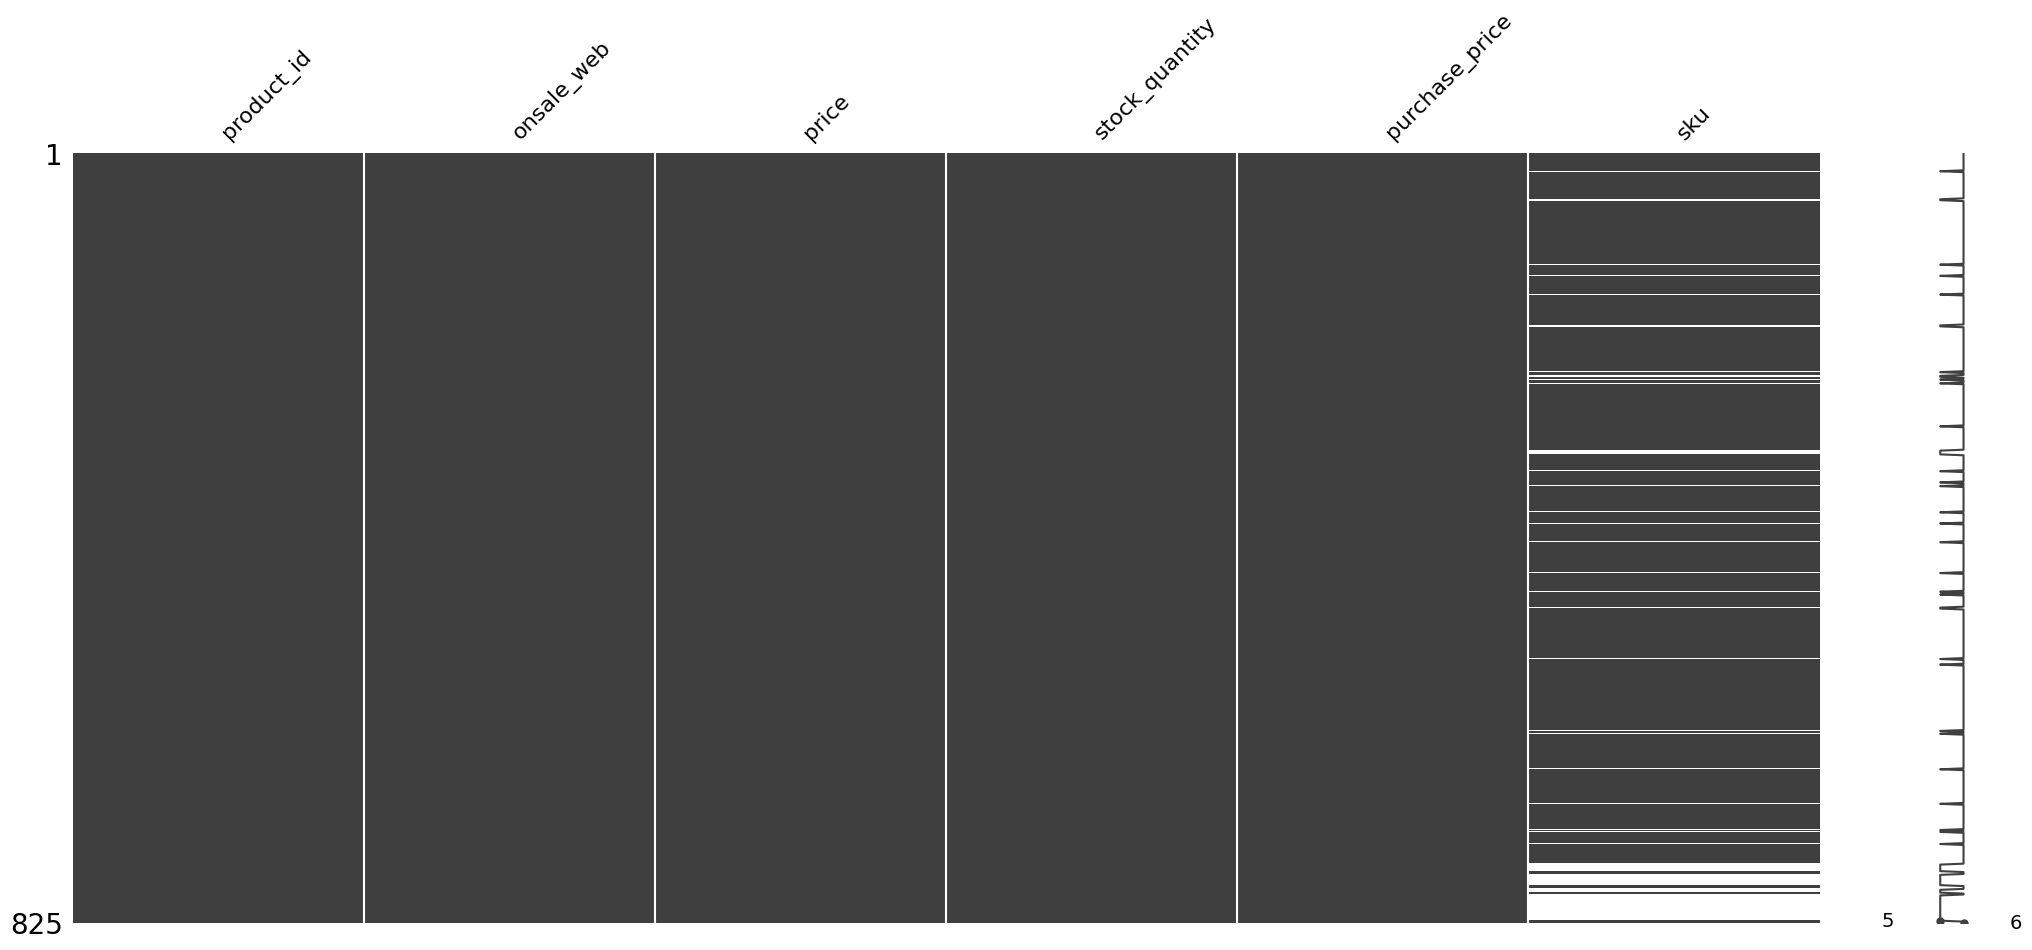

In [80]:
#Fusion des fichiers df_erp et df_liaison
msno.matrix(df_merge)

In [81]:
df_merge = df_merge.query('sku == sku')
df_merge['sku'] = df_merge['sku'].astype(str)
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 734 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      734 non-null    object 
 1   onsale_web      734 non-null    bool   
 2   price           734 non-null    float64
 3   stock_quantity  734 non-null    int64  
 4   purchase_price  734 non-null    float64
 5   sku             734 non-null    object 
dtypes: bool(1), float64(2), int64(1), object(2)
memory usage: 35.1+ KB


/tmp/ipython-input-81-1403451310.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [82]:
#Y a t-il des lignes ne "matchant" entre les 2 fichiers?
df = pd.merge(
    df_erp,
    df_liaison,
    on='product_id',
    how='outer',
    indicator=True
)
df['_merge'].value_counts()


,count
_merge,
both,825
left_only,0
right_only,0


- both (825 lignes) toutes les lignes de df_erp et de df_liaison ont trouvé un correspondant sur la clé de jointure.

In [83]:
df_web.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 1391
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           714 non-null    object 
 1   total_sales   714 non-null    float64
 2   product_type  714 non-null    object 
 3   post_title    714 non-null    object 
dtypes: float64(1), object(3)
memory usage: 27.9+ KB


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [84]:
df_web.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 1391
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           714 non-null    object 
 1   total_sales   714 non-null    float64
 2   product_type  714 non-null    object 
 3   post_title    714 non-null    object 
dtypes: float64(1), object(3)
memory usage: 27.9+ KB


In [85]:
#Fusionnez les datasets df_merge et df_web
df_final = pd.merge(df_web, df_merge, on=['sku'], how='left')
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sku             714 non-null    object 
 1   total_sales     714 non-null    float64
 2   product_type    714 non-null    object 
 3   post_title      714 non-null    object 
 4   product_id      714 non-null    object 
 5   onsale_web      714 non-null    bool   
 6   price           714 non-null    float64
 7   stock_quantity  714 non-null    int64  
 8   purchase_price  714 non-null    float64
dtypes: bool(1), float64(3), int64(1), object(4)
memory usage: 45.5+ KB


In [86]:
df_final = df_final[['product_id', 'sku', 'onsale_web', 'post_title', 'product_type', 'price', 'purchase_price', 'stock_quantity', 'total_sales']]
df_final.head()

,product_id,sku,onsale_web,post_title,product_type,price,purchase_price,stock_quantity,total_sales
0,4069,11862,True,Gilles Robin Hermitage Rouge 2012,Vin,60.0,30.07,4,3.0
1,4673,16057,True,Domaine Pellé Sancerre Rouge La Croix Au Garde...,Vin,19.8,10.33,17,5.0
2,5794,14692,True,Château Fonréaud Bordeaux Blanc Le Cygne 2016,Vin,21.7,10.65,15,5.0
3,4200,16295,False,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,Vin,5.8,3.12,33,14.0
4,5827,15328,True,Agnès Levet Côte Rôtie Maestria 2017,Vin,55.0,29.55,4,2.0


In [87]:
df_final.nunique()

,0
product_id,714
sku,714
onsale_web,2
post_title,711
product_type,7
price,362
purchase_price,590
stock_quantity,80
total_sales,27


In [88]:
#Avons-nous des lignes sans correspondances?
print(df_final.shape)

(714, 9)


In [89]:
missing_counts = df_final.isnull().sum()
print(missing_counts)

product_id        0
sku               0
onsale_web        0
post_title        0
product_type      0
price             0
purchase_price    0
stock_quantity    0
total_sales       0
dtype: int64


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univarié des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<Axes: >

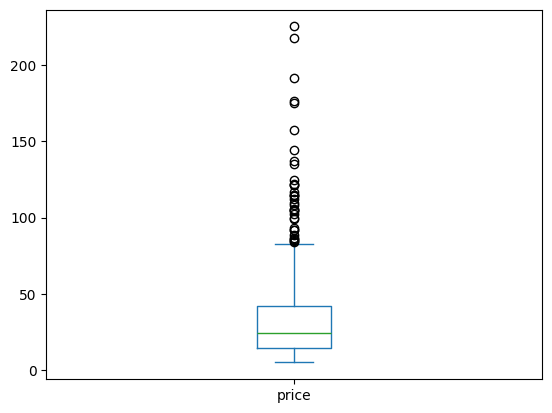

In [90]:
#Création d'une Boite à moustache de la répartition des prix grâce à Pandas
df_erp['price'].plot.box()

In [91]:
#Autre méthode avec plotly express
fig = px.box(df_erp, y="price",
             title="Répartition des prix")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utisation de méthodes statistique</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [92]:
#Calculer la moyenne du prix
moyenne_prix = df_merge["price"].mean()
print(f"La moyenne du prix est : {moyenne_prix:.2f}€")

#Calculer l'écart-type du prix
ecart_type_prix = df_merge["price"].std()
print(f"L'écart-type du prix est : {ecart_type_prix:.2f}€")

#Calculer le Z-score
#Calcul manuel du Z-score pour la colonne 'price'
df_merge["price_zscore"] = (df_merge["price"] - df_merge["price"].mean()) / df_merge["price"].std()

# Affichage des premières valeurs pour vérifier
print(df_merge[["price", "price_zscore"]])

La moyenne du prix est : 32.06€
L'écart-type du prix est : 27.31€
     price  price_zscore
0     24.2     -0.287836
1     34.3      0.081946
2     20.8     -0.412317
3     14.1     -0.657618
4     46.0      0.510307
..     ...           ...
792   27.5     -0.167016
793   69.0      1.352385
822   54.8      0.832493
823   26.5     -0.203629
824   16.3     -0.577072

[734 rows x 2 columns]


In [93]:
# Calcul du Z-score via scipy.stats
df_erp["price_zscore"] = stats.zscore(df_erp["price"])

# Affichage des résultats
print(df_erp[["price", "price_zscore"]].head())

   price  price_zscore
0   24.2     -0.303818
1   34.3      0.076066
2   20.8     -0.431700
3   14.1     -0.683702
4   46.0      0.516129


In [94]:
#Quel est le seuil prix dont z-score est supérieur à 3?
seuil_prix = moyenne_prix + 3 *ecart_type_prix

print(f"Le seuil de prix dont le z-score est supérieur à 3 est: {seuil_prix:.2f}€")

Le seuil de prix dont le z-score est supérieur à 3 est: 114.00€


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'interval interquartile</h3>
</div>

In [95]:
# On calcule les quartiles
Q1 = df_merge['price'].quantile(0.25)
Q3 = df_merge['price'].quantile(0.75)
IQR = Q3 - Q1
coef = IQR*1.5

In [96]:
# On calcule les valeurs limite
lim_inf = Q1 - coef
lim_sup = Q3 + coef

print(lim_inf)
print(lim_sup)

-27.543749999999996
83.40625


In [97]:
#Utilisation de la fonction describe de Pandas pour l'etude des mesures de dispersions
stats_zscore = df_merge["price_zscore"].describe()
print(stats_zscore)

count    734.000000
mean       0.000000
std        1.000000
min       -0.983466
25%       -0.658991
50%       -0.320787
75%        0.356536
max        7.063869
Name: price_zscore, dtype: float64


In [98]:
#Définissez un seuil pour les articles "outliers" en prix
df_outliers = df_merge[df_merge["price_zscore"] > 3]
df_outliers_sorted = df_merge[df_merge["price_zscore"] > 3].sort_values(by="price_zscore", ascending=True)
print(df_outliers_sorted)

    product_id  onsale_web  price  stock_quantity  purchase_price    sku  \
711       6215        True  115.0              14           56.45  12790   
708       6212        True  115.0              16           59.42  13996   
703       6202        True  116.4              12           63.15  15126   
709       6213        True  121.0               9           63.14  15072   
712       6216        True  121.0              14           60.02  15070   
651       5917        True  122.0              12           54.24  14775   
556       5612        True  124.8              19           66.41  14915   
697       6126        True  135.0             138           80.33  14923   
411       4904        True  137.0               9           67.95  14220   
230       4406        True  157.0              12           69.08   7819   
598       5767        True  175.0              12           90.42  15185   
227       4402        True  176.0              11           78.25   3510   
635       58

In [99]:
#Définissez le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
pcrtg_zscore_over_3 = (len(df_outliers) / len(df_erp)) *100
print(f"Le pourcentage d'observations avec un z-score supérieur à 3 est de : {pcrtg_zscore_over_3:.2f}%")

Le pourcentage d'observations avec un z-score supérieur à 3 est de : 1.82%


In [100]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?


Ces outliers sont justifiés eu égard au marché des boissons alcoolisées et plus particulièrement sur le segment des vins spiritueux.

En effet dans ce marché de niche premium, l'écart est un important et la large densité des prix réside dans la stratégie commerciale menée par l'entreprise.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univarié du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivarié  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [101]:
##############################
# Calculer le CA du site web #
##############################

#Créez une colonne calculant le CA par article
df_final['ca'] = df_final['price'] * df_final['total_sales']


#Calculez la somme de la colonne "ca_par_article"
total_ca = df_final['ca'].sum()

#Ce résultat correspond au chiffre d'affaire du site web
print(f"Le chiffre d'affaires du site web est de: {total_ca:.2f}€")

Le chiffre d'affaires du site web est de: 153748.10€


In [102]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      714 non-null    object 
 1   sku             714 non-null    object 
 2   onsale_web      714 non-null    bool   
 3   post_title      714 non-null    object 
 4   product_type    714 non-null    object 
 5   price           714 non-null    float64
 6   purchase_price  714 non-null    float64
 7   stock_quantity  714 non-null    int64  
 8   total_sales     714 non-null    float64
 9   ca              714 non-null    float64
dtypes: bool(1), float64(4), int64(1), object(4)
memory usage: 51.0+ KB


In [103]:
###############################
# Palmares des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_web
df_final = df_final.sort_values(by='ca', ascending=False)


#Réinitialiser l'index du dataset par un reset_index
df_final = df_final.sort_values(by="ca", ascending=False).reset_index(drop=True)

#Afficher les 20 premier articles en CA
display(df_final.head(20))

#Graphique en barre des 20 premiers articles avec plotly express
# Extraction des 20 premiers articles
top20 = df_final.head(20)

,product_id,sku,onsale_web,post_title,product_type,price,purchase_price,stock_quantity,total_sales,ca
0,4150,1366,True,Champagne Mailly Grand Cru Intemporelle 2010,Champagne,59.0,35.45,123,116.0,6844.0
1,4352,15940,True,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Champagne,225.0,137.81,0,11.0,2475.0
2,4726,14950,True,François Baur Pinot Noir Schlittweg 2017,Vin,12.7,6.82,0,122.0,1549.4
3,5067,15346,True,Albert Mann Pinot Noir Grand H 2017,Vin,59.9,30.95,3,22.0,1317.8
4,5379,14561,True,Argentine Mendoza Alamos Torrontes 2017,Vin,11.1,5.68,33,111.0,1232.1
5,5892,14983,True,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Champagne,191.3,116.06,98,6.0,1147.8
6,4353,12587,True,Champagne Egly-Ouriet Grand Cru Brut Rosé,Champagne,79.5,45.91,127,14.0,1113.0
7,5826,15325,True,Agnès Levet Côte Rôtie Améthyste 2017,Vin,41.2,21.71,34,20.0,824.0
8,6212,13996,True,Domaine des Comtes Lafon Volnay 1er Cru Santen...,Vin,115.0,59.42,16,7.0,805.0
9,5026,13913,True,Champagne Agrapart &amp; Fils Minéral Extra Br...,Champagne,86.8,50.13,101,9.0,781.2


In [104]:
# Définir le groupe de couleur en fonction du début du post_title
top20["color_group"] = top20["post_title"].apply(
    lambda x: "champagne" if x.lower().startswith("champagne")
              else ("cognac" if x.lower().startswith("cognac")
                    else "vin")
)

# Création du graphique à barres horizontal
fig = px.bar(
    top20,
    x="ca",                    # Axe x pour le chiffre d'affaires
    y="post_title",            # Axe y pour le titre de l'article, affiché à gauche
    orientation="h",           # Orientation horizontale
    color="color_group",       # Définir la couleur par groupe
    text="ca",                 # Affiche la valeur de CA sur chaque barre
    color_discrete_map={       # Attribution des couleurs
        "champagne": "gold",
        "cognac": "gray",
        "vin": "red"
    },
    title="Top 20 des articles par CA"
)

# Positionner le texte en dehors des barres pour qu'il soit lisible
fig.update_traces(textposition='outside')

# Ajuster la mise en page pour un affichage plus lisible
fig.update_layout(
    xaxis_title="Chiffre d'Affaires",
    yaxis_title="Article",
    margin=dict(l=200, r=50, t=50, b=50),  # Agrandir la marge à gauche pour les titres longs
    height=600,                           # Hauteur du graphique
    font=dict(size=12)                    # Taille de police adaptée
)

fig.show()


/tmp/ipython-input-104-2932867539.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [105]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_final['%_ca'] = (df_final['ca'] / df_final['ca'].sum())* 100
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_final['cumulatif_%_ca'] = df_final['%_ca'].cumsum().round(2)
#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
ca_80 = (df_final['cumulatif_%_ca'] <= 80).sum()
#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
print(f"Nombre d'articles représentant 80% du CA : {ca_80}")

Nombre d'articles représentant 80% du CA : 421


In [106]:
# Pour que le graphique reste lisible, on peut trier le dataset par CA décroissant (si ce n'est pas déjà fait)
df_final = df_final.sort_values(by="ca", ascending=False).reset_index(drop=True)

# Création du graphique
fig = go.Figure()

# Trace des barres représentant la part individuelle de CA (%_ca)
fig.add_trace(go.Bar(
    x=df_final.index,           # index ou numéro d'article
    y=df_final['%_ca'],          # part du CA par article en %
    name='% du CA par article',
    marker_color='lightblue'
))

# Trace de la courbe cumulative (% de CA cumulé)
fig.add_trace(go.Scatter(
    x=df_final.index,
    y=df_final['cumulatif_%_ca'],
    mode='lines+markers',
    name='Cumulatif % du CA',
    marker_color='darkblue'
))

# Ajout d'une ligne horizontale indiquant le seuil à 80%
fig.add_shape(
    type='line',
    x0=df_final.index.min(),    # début sur l'axe x
    x1=df_final.index.max(),    # fin sur l'axe x
    y0=80,
    y1=80,
    line=dict(color='red', dash='dash'),
)

# Annotation pour la ligne à 80%
fig.add_annotation(
    x=df_final.index.max(),
    y=80,
    text="80%",
    showarrow=False,
    font=dict(color="red", size=12)
)

# Mise en forme du graphique pour un affichage lisible
fig.update_layout(
    title="Répartition du CA par article - Analyse Pareto",
    xaxis_title="Articles (index trié par CA décroissant)",
    yaxis_title="Pourcentage (%)",
    legend_title="Légende",
    margin=dict(l=80, r=50, t=80, b=50),
    height=600
)

fig.show()


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en Quantités</h3>
</div>

In [107]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      714 non-null    object 
 1   sku             714 non-null    object 
 2   onsale_web      714 non-null    bool   
 3   post_title      714 non-null    object 
 4   product_type    714 non-null    object 
 5   price           714 non-null    float64
 6   purchase_price  714 non-null    float64
 7   stock_quantity  714 non-null    int64  
 8   total_sales     714 non-null    float64
 9   ca              714 non-null    float64
 10  %_ca            714 non-null    float64
 11  cumulatif_%_ca  714 non-null    float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 62.2+ KB


In [108]:
#####################################
# Palmares des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_final_sorted = df_final.sort_values(by='total_sales', ascending=False).reset_index(drop=True)
#Réinitialiser l'index du dataset par un reset_index

#Afficher les 20 premier articles en quantité
top_20_sales = df_final_sorted.head(20)
display(top_20_sales)
#Graphique en barre des 20 premiers articles avec plotly express

# Définir le groupe de couleur en fonction du début du post_title
top_20_sales["color_group"] = top_20_sales["post_title"].apply(
    lambda x: "champagne" if x.lower().startswith("champagne")
              else ("cognac" if x.lower().startswith("cognac")
                    else "vin")
)


fig = px.bar(top_20_sales,
             x="total_sales",
             y="post_title",
             orientation="h",
             title="Top 20 des articles par quantité vendue",
             labels={"total_sales": "Quantité vendue", "post_title": "Article",
            })

fig.update_layout(
    xaxis_title="Quantité vendue",
    yaxis_title="Article",
    yaxis={'categoryorder':'total ascending'},
    margin=dict(l=200, r=50, t=50, b=50),
    height=600,
    font=dict(size=12)
)

fig.show()


,product_id,sku,onsale_web,post_title,product_type,price,purchase_price,stock_quantity,total_sales,ca,%_ca,cumulatif_%_ca
0,4726,14950,True,François Baur Pinot Noir Schlittweg 2017,Vin,12.7,6.82,0,122.0,1549.4,1.007752,7.07
1,4150,1366,True,Champagne Mailly Grand Cru Intemporelle 2010,Champagne,59.0,35.45,123,116.0,6844.0,4.451437,4.45
2,5379,14561,True,Argentine Mendoza Alamos Torrontes 2017,Vin,11.1,5.68,33,111.0,1232.1,0.801376,8.73
3,4867,16148,True,Château De La Selve IGP Coteaux de l'Ardèche M...,Vin,9.9,4.86,121,36.0,356.4,0.231808,28.42
4,4203,15415,True,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,Vin,9.9,5.01,74,27.0,267.3,0.173856,44.31
5,4275,14864,True,I Fabbri Chianti Classico Lamole 2017,Vin,14.9,7.78,62,24.0,357.6,0.232588,27.26
6,5067,15346,True,Albert Mann Pinot Noir Grand H 2017,Vin,59.9,30.95,3,22.0,1317.8,0.857116,7.93
7,4647,16525,True,Bernard Baudry Chinon Rouge La Croix Boissée 2017,Vin,28.5,14.14,45,22.0,627.0,0.407810,14.80
8,6129,14570,True,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,Vin,5.2,2.74,68,20.0,104.0,0.067643,95.44
9,5826,15325,True,Agnès Levet Côte Rôtie Améthyste 2017,Vin,41.2,21.71,34,20.0,824.0,0.535942,10.73


/tmp/ipython-input-108-4022857971.py:15: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [109]:
# Trier le DataFrame par ordre décroissant de quantités vendues et réinitialiser l'index
df_final_sorted = df_final.sort_values(by='total_sales', ascending=False).reset_index(drop=True)

# Sélectionner les 20 premiers articles
top_20_sales = df_final_sorted.head(20)

# Définir le groupe de couleur en fonction du début du post_title
top_20_sales["color_group"] = top_20_sales["post_title"].apply(
    lambda x: "champagne" if x.lower().startswith("champagne")
              else ("cognac" if x.lower().startswith("cognac")
                    else "vin")
)

# Création du graphique en barre horizontal en incluant le paramètre 'color'
fig = px.bar(
    top_20_sales,
    x="total_sales",
    y="post_title",
    orientation="h",
    title="Top 20 des articles par quantité vendue",
    labels={"total_sales": "Quantité vendue", "post_title": "Article"},
    color="color_group",  # ici, nous spécifions la variable de couleur
    color_discrete_map={  # et nous mappons les groupes à des couleurs précises
        "champagne": "gold",
        "cognac": "gray",
        "vin": "red"
    }
)

fig.update_layout(
    xaxis_title="Quantité vendue",
    yaxis_title="Article",
    yaxis={'categoryorder':'total ascending'},
    margin=dict(l=200, r=50, t=50, b=50),
    height=600,
    font=dict(size=12)
)

fig.show()


/tmp/ipython-input-109-3693517164.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [110]:
display(top_20_sales)

,product_id,sku,onsale_web,post_title,product_type,price,purchase_price,stock_quantity,total_sales,ca,%_ca,cumulatif_%_ca,color_group
0,4726,14950,True,François Baur Pinot Noir Schlittweg 2017,Vin,12.7,6.82,0,122.0,1549.4,1.007752,7.07,vin
1,4150,1366,True,Champagne Mailly Grand Cru Intemporelle 2010,Champagne,59.0,35.45,123,116.0,6844.0,4.451437,4.45,champagne
2,5379,14561,True,Argentine Mendoza Alamos Torrontes 2017,Vin,11.1,5.68,33,111.0,1232.1,0.801376,8.73,vin
3,4867,16148,True,Château De La Selve IGP Coteaux de l'Ardèche M...,Vin,9.9,4.86,121,36.0,356.4,0.231808,28.42,vin
4,4203,15415,True,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,Vin,9.9,5.01,74,27.0,267.3,0.173856,44.31,vin
5,4275,14864,True,I Fabbri Chianti Classico Lamole 2017,Vin,14.9,7.78,62,24.0,357.6,0.232588,27.26,vin
6,5067,15346,True,Albert Mann Pinot Noir Grand H 2017,Vin,59.9,30.95,3,22.0,1317.8,0.857116,7.93,vin
7,4647,16525,True,Bernard Baudry Chinon Rouge La Croix Boissée 2017,Vin,28.5,14.14,45,22.0,627.0,0.407810,14.80,vin
8,6129,14570,True,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,Vin,5.2,2.74,68,20.0,104.0,0.067643,95.44,vin
9,5826,15325,True,Agnès Levet Côte Rôtie Améthyste 2017,Vin,41.2,21.71,34,20.0,824.0,0.535942,10.73,vin


In [111]:
#############################
# Calculer le 20 / 80 en CA #
#############################

# On suppose que df_final contient déjà la colonne "total_sales" qui représente les quantités vendues.
# 1. Créer une colonne calculant la part en quantité de chaque article
df_final['%_quantite'] = (df_final['total_sales'] / df_final['total_sales'].sum()) * 100

# 2. Créer une colonne réalisant la somme cumulative de la colonne précédemment calculée
df_final['cumulatif_%_quantite'] = df_final['%_quantite'].cumsum().round(2)

# 3. Calculer le nombre d'articles représentant 80% des ventes en quantité
# On compte le nombre de lignes où le cumul est inférieur ou égal à 80.
articles_80 = (df_final['cumulatif_%_quantite'] <= 80).sum()

# 4. Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier
proportion_articles_80 = (articles_80 / len(df_final)) * 100

print(f"Nombre d'articles représentant 80% des ventes en quantité : {articles_80}")
print(f"Ces articles représentent {proportion_articles_80:.2f}% du catalogue total.")


Nombre d'articles représentant 80% des ventes en quantité : 534
Ces articles représentent 74.79% du catalogue total.


In [112]:
fig = go.Figure()

# Barre pour la contribution individuelle en pourcentage (%_quantite)
fig.add_trace(go.Bar(
    x=df_final.index,
    y=df_final['%_quantite'],
    name="Contribution individuelle (%)",
    marker_color="lightblue"
))

# Courbe de la somme cumulative (% cumulatif)
fig.add_trace(go.Scatter(
    x=df_final.index,
    y=df_final['cumulatif_%_quantite'],
    mode="lines+markers",
    name="Cumulatif (%)",
    line=dict(color="darkblue")
))

# Ligne horizontale à 80%
fig.add_shape(
    type="line",
    x0=df_final.index.min(),
    x1=df_final.index.max(),
    y0=80,
    y1=80,
    line=dict(color="red", dash="dash"),
)

# Annotation pour signaler le seuil à 80%
fig.add_annotation(
    x=df_final.index.max(),
    y=80,
    text="80%",
    showarrow=False,
    font=dict(color="red", size=12)
)

# Mise à jour de la mise en forme du graphique pour une lecture optimale
fig.update_layout(
    title="Répartition en quantité des articles - Analyse Pareto (80% des ventes)",
    xaxis_title="Articles (index trié par quantités vendues décroissantes)",
    yaxis_title="Pourcentage (%)",
    legend_title="Légende",
    margin=dict(l=80, r=50, t=80, b=50),
    height=600,
)

fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [113]:
######################################
# Calcule le nombre de mois de stock #
######################################


# 1. Calcul du nombre de mois de stock

# La formule est : nombre de mois de stock = stock_quantity / total_sales
df_final["mois_stock"] = df_final["stock_quantity"] / df_final["total_sales"]

# 2. Remplacement des valeurs infinies par 0
# Ces valeurs peuvent apparaître lorsque total_sales est 0.
df_final["mois_stock"].replace([np.inf, -np.inf], 0, inplace=True)

#  3. Tri par nombre de mois de stock
# On trie dans l'ordre décroissant et on réinitialise l'index
df_final_sorted = df_final.sort_values(by="mois_stock", ascending=False).reset_index(drop=True)

# Extraction du flop 20 des produits (ceux ayant le plus de mois de stock)
flop_20 = df_final_sorted.head(20).copy()

#  4. Initialisation de la colonne "color_group"
# En fonction du début du post_title, on attribue :
#   - "champagne" si le titre commence par "champagne"
#   - "cognac" si le titre commence par "cognac"
#   - Sinon "vin" pour toutes les autres valeurs
flop_20["color_group"] = flop_20["post_title"].apply(
    lambda x: "champagne" if x.lower().startswith("champagne")
              else ("cognac" if x.lower().startswith("cognac")
                    else "vin")
)

# Définition du mapping des couleurs pour chaque groupe
color_map = {
    "champagne": "gold",
    "cognac": "gray",
    "vin": "red"
}

#  5. Création du graphique en barre horizontal avec Plotly Express
fig = px.bar(
    flop_20,
    x="mois_stock",         # Axe x : nombre de mois de stock
    y="post_title",         # Axe y : titre du produit (affiché à gauche)
    orientation="h",        # Graphique horizontal
    title="Flop 20 des produits avec le plus de mois de stock",
    labels={"mois_stock": "Nombre de mois de stock", "post_title": "Produit"},
    color="color_group",    # Utilisation de la colonne de couleur configurée
    color_discrete_map=color_map  # Mapping personnalisé des couleurs
)

# Ajustement de la mise en page pour améliorer la lisibilité
fig.update_layout(
    xaxis_title="Nombre de mois de stock",
    yaxis_title="Produit",
    yaxis={'categoryorder': 'total ascending'},
    margin=dict(l=150, r=50, t=50, b=50),
    height=600,
    font=dict(size=12)
)

fig.show()


/tmp/ipython-input-113-910024281.py:13: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [114]:
####################################
# Valorisation des stocks en euros #
####################################

# Création de la colonne "Valorisation_stock_euros"
df_final['Valorisation_stock_euros'] = df_final['stock_quantity'] * df_final['price']

# Calcul de la somme de la colonne "Valorisation_stock_euros"
total_valorisation = df_final['Valorisation_stock_euros'].sum()

# Afficher le résultat
print(f"La valorisation totale des stocks en euros est : {total_valorisation:.2f} €")


La valorisation totale des stocks en euros est : 494682.40 €


In [115]:
##############################################
# Valorisation du nombre de produit en stock #
##############################################

#Calculer la somme de la colonne stock quantity
total_stock_quantity = df_final['stock_quantity'].sum()
print(f"La somme totale de la colonne stock_quantity est : {total_stock_quantity:.2f}€")


La somme totale de la colonne stock_quantity est : 16741.00€


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [116]:
############################
# Analyse du taux de marge #
############################
# 1. Création de la colonne "prix_HT"
# On part du principe que la TVA est de 20%, donc on divise le prix TTC par 1.2 pour obtenir le prix HT.
df_final["prix_HT"] = (df_final["price"] / 1.2).round(2)

# 2. Création de la colonne "taux_marge"
# Le taux de marge se calcule par : (prix_HT - cost) / prix_HT * 100
df_final["taux_marge"] = (((df_final["prix_HT"] - df_final["purchase_price"]) / df_final["prix_HT"]) * 100).round(2)

In [117]:
# Filtrer les observations avec un taux de marge inférieur à 0
observations_negatives = df_final.query("taux_marge < 0")

# Trouver l'index de l'observation présentant le taux de marge le plus faible (c'est-à-dire le minimum)
index_min_neg = observations_negatives['taux_marge'].idxmin()

# Afficher cette observation (la ligne avec le taux de marge le plus négatif)
print("Observation avec le taux de marge le plus négatif:")
display(df_final.loc[index_min_neg])

Observation avec le taux de marge le plus négatif:


,697
product_id,4355
sku,12589
onsale_web,True
post_title,Champagne Egly-Ouriet Grand Cru Blanc de Noirs
product_type,Champagne
price,12.65
purchase_price,77.48
stock_quantity,97
total_sales,0.0
ca,0.0


In [118]:
#création d'un dataframe avec les taux positifs
observations_positives = df_final.query("taux_marge > 0")

#Afficher le prix minimum de la colonne "taux_marge"
min_taux = observations_positives["taux_marge"].min()
print(f"Le taux de marge minimum est de : {min_taux:.2f}%")

#Afficher le prix maximum de la colonne "taux_marge"
max_taux = observations_positives["taux_marge"].max()
print(f"Le taux de marge maximum est de : {max_taux:.2f}%")

Le taux de marge minimum est de : 22.80%
Le taux de marge maximum est de : 47.75%


In [119]:
#création d'un dataframe avec le taux de marge moyen par type de produit
df_marge_moyenne = df_final.groupby("product_type", as_index=False)["taux_marge"].mean()

print(f"Taux de marge moyen par type de produit :{df_marge_moyenne}")

#Affichage dans un graphique du taux de marge par type de produit
fig = px.bar(
    df_marge_moyenne,
    x="product_type",
    y="taux_marge",
    title="Taux de marge moyen par type de produit",
    labels={
        "product_type": "Type de produit",
        "taux_marge": "Taux de marge moyen (%)"
    },
    color="taux_marge",  # Optionnel : permet d'ajouter un gradien de couleur selon la valeur
    color_continuous_scale="Viridis"  # Choix d'une palette de couleurs
)

fig.update_layout(
    xaxis_title="Type de produit",
    yaxis_title="Taux de marge moyen (%)",
    margin=dict(l=80, r=50, t=50, b=50),
    font=dict(size=12)
)

fig.show()

Taux de marge moyen par type de produit :    product_type  taux_marge
0          Autre   36.150000
1      Champagne    4.787857
2         Cognac   45.068750
3            Gin   42.800000
4  Huile d'olive   25.006667
5            Vin   38.012371
6         Whisky   44.920000


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des correlations entre les variables stock, sales et price</h3>
</div>

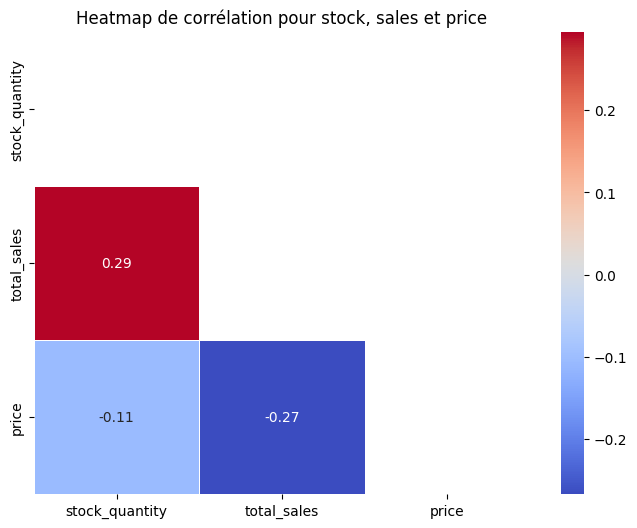

In [120]:
############################
# Analyse des correlations #
############################

#Création d'un heatmap de correlation avec les variables stock, sales et price
#on peut également créer un mask pour n'afficher qu'une demi heatmap

variables = ['stock_quantity', 'total_sales', 'price']
df_corr = df_final[variables]

# Calcul de la matrice de corrélation
corr_matrix = df_corr.corr()

# Création d'un masque : ici, on masque la moitié supérieure (ou inférieure) de la matrice
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Paramétrage de l'affichage de la heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap de corrélation pour stock, sales et price")
plt.show()


In [121]:
#Que peut-on conclure des correlations ?

***Interprétation des coefficients de corrélation : ***
-** Prix et stock** : La corrélation de -0,11 suggère très peu de lien : les produits plus chers ont tendance, de manière négligeable, à avoir un stock légèrement inférieur.

- **Prix et ventes** : Avec -0,27, il apparaît modérément que des prix élevés peuvent freiner les ventes.

- **Stock et ventes** : La corrélation positive de 0,29 indique qu’un stock plus important est associé à des ventes supérieures.

En définitif, Les relations observées sont faibles à modérées, ce qui montre que ni le prix, ni le stock ne sont des déterminants majeurs des ventes. D’autres facteurs restent à explorer pour mieux comprendre ces dynamiques.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mettre à disposition la nouvelle table sur un fichier Excel</h3>
</div>

In [122]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut-être utile pour partager le résultat du dataset obtenu pour le partager avec les équipes.

df_merge.to_excel("dataset_final.xlsx", sheet_name="Résultats", index=False)
print("Le dataset df_merge a été enregistré dans 'dataset_final.xlsx'")

Le dataset df_merge a été enregistré dans 'dataset_final.xlsx'
